In [12]:
import matplotlib.pyplot as plt
import numpy as np

# from scipy.signal import lombscargle as lombs
from wattson.models.power_supply import Battery
from wattson.models.database import Database

In [13]:
# battery = Battery()
database = Database()

In [14]:
df = database.get_data()

/home/tortugellini/git/wattson/src/wattson/models/database.py:44: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT * FROM {self.database}", con=self.connection)


In [15]:
df["time"] = df['time'].astype("float64")

In [16]:
df["time"] = df["time"] / 1000 # Converting from milliseconds to seconds.

In [17]:
df.set_index("time", inplace=True)

In [19]:
time = df.index.to_numpy()
voltage = df.voltage.to_numpy()
energy = df.energy.to_numpy()
charge = energy / voltage
current = np.gradient(charge, time)

In [20]:
voltage_changes = np.diff(voltage)

<Axes: xlabel='time'>

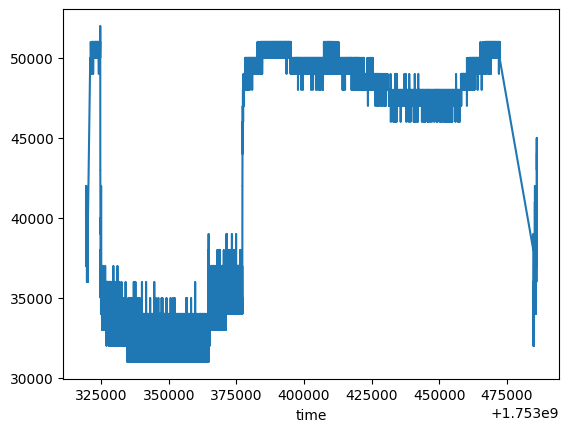

In [24]:
df["wifi_temp"].plot()

In [ ]:
# TODO: Make object to hold and handle chemical reactions, thermodynamic quantities, and perform thermodynamic calculations.
# TODO: Fix database so it uses SQLAlchemy.